<a href="https://colab.research.google.com/github/juwon-ds/practice-data-analysis/blob/main/notebooks/day7_pandas.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [4]:
import pandas as pd

In [5]:
student_info = {
    'name': ['Juwon', 'Minji', 'Alex', 'Sara', 'Tom'],
    'gender': ['F', 'F', 'M', 'F', 'M'],
    'age': [20, 21, 19, 22, 20]
}

df1 = pd.DataFrame(student_info)

In [6]:
score_data = {
    'name': ['Juwon', 'Minji', 'Alex', 'Sara', 'Tom'],
    'math': [85, 90, 65, 88, 95],
    'english': [80, 92, 70, 85, 90]
}

df2 = pd.DataFrame(score_data)

In [8]:
df = pd.merge(df1,df2)
print(df)

    name gender  age  math  english
0  Juwon      F   20    85       80
1  Minji      F   21    90       92
2   Alex      M   19    65       70
3   Sara      F   22    88       85
4    Tom      M   20    95       90


In [14]:
df['ave_score'] = df[['math','english']].mean(axis=1)
df

# axis = 0 : 세로 (컬럼 기준)
# axis = 1 : 가로 (행 기준)
# 여기서는 한 사람의 점수 평균이니 가로로 더해야 해서 axis = 1

,name,gender,age,math,english,ave_score
0,Juwon,F,20,85,80,82.5
1,Minji,F,21,90,92,91.0
2,Alex,M,19,65,70,67.5
3,Sara,F,22,88,85,86.5
4,Tom,M,20,95,90,92.5


# pivot_table
: 데이터를 기준별로 묶어서 평균/합계 등의 값을 계산하는 것

df.pivot_table(
    values = '분석할 값',
    index = '기준 (행)',
    columns = '추가 기준 (선택)',
    aggfunc = 'mean'
)


groupby 보다 좋은 점
*   행, 열 둘 다 기준으로 사용 가능
*   표 형태로 정리됨



In [16]:
df.pivot_table(
    values = 'ave_score',
    index = 'gender',
    aggfunc = 'mean'
)

,ave_score
gender,
F,86.666667
M,80.000000


In [17]:
df.pivot_table(
    values = ['math','english'],
    index = 'gender',
    aggfunc = 'mean'
)

,english,math
gender,,
F,85.666667,87.666667
M,80.000000,80.000000


In [18]:
df.pivot_table(
    values = 'ave_score',
    index = 'gender',
    columns = 'age'
)

age,19,20,21,22
gender,,,,
F,NaN,82.5,91.0,86.5
M,67.5,92.5,NaN,NaN


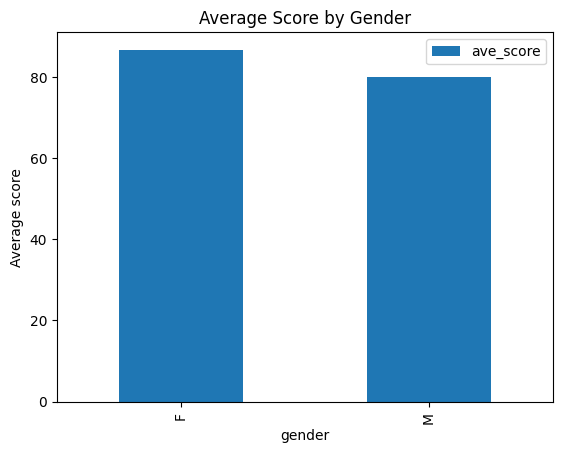

In [21]:
import matplotlib.pyplot as plt

pivot_df = df.pivot_table(
    values = 'ave_score',
    index = 'gender'
)
pivot_df.plot(kind='bar')
plt.title('Average Score by Gender')
plt.xlabel('gender')
plt.ylabel('Average score')
plt.show()

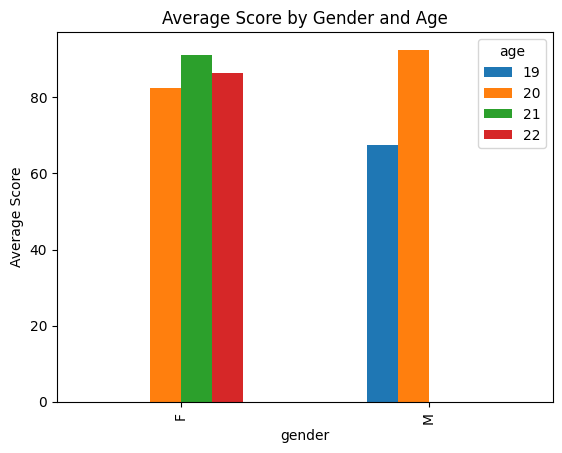

In [22]:
pivot_df2 = df.pivot_table(
    values = 'ave_score',
    index = 'gender',
    columns = 'age'
)
pivot_df2.plot(kind='bar')
plt.title('Average Score by Gender and Age')
plt.xlabel('gender')
plt.ylabel('Average Score')
plt.show()

Conclusion

*   Female students tend to have higher average scores than male students.
*   There is no consistent relationship between age and average score.
*   Scores vary within each gender depending on age.




